In [1]:
!pip install imbalanced-learn xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import glob, os, time, warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded successfully")
print("TensorFlow version:", tf.__version__)

Mounted at /content/drive
All libraries loaded successfully
TensorFlow version: 2.20.0


In [3]:
path = "/content/drive/MyDrive/CICIDS2017/"

files = glob.glob(os.path.join(path, "*.csv"))
print(f"Found {len(files)} files:")
for f in files:
    print(" -", os.path.basename(f))

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df.columns = df.columns.str.strip()

print("\nTotal records loaded:", len(df))
print("Columns:", df.shape[1])

Found 8 files:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv

Total records loaded: 2830743
Columns: 79


In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df["Label"] = df["Label"].astype(str).str.strip()
df["Label"] = (
    df["Label"]
      .str.replace("�", "-", regex=False)
      .str.replace("–", "-", regex=False)
      .str.replace("—", "-", regex=False)
      .str.replace("  ", " ", regex=False)
)

print("Records after cleaning:", len(df))
print("\nLabel distribution:")
print(df["Label"].value_counts())
print("\nUnique labels:")
print(sorted(df["Label"].unique()))

Records after cleaning: 2520798

Label distribution:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Unique labels:
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [5]:
feature_cols = [c for c in df.columns if c != "Label" and pd.api.types.is_numeric_dtype(df[c])]

print("Number of numeric feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

le = LabelEncoder()
df["LabelEncoded"] = le.fit_transform(df["Label"])

print("\nEncoded classes:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Number of numeric feature columns: 78
First 10 feature columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Encoded classes:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> DoS GoldenEye
4 -> DoS Hulk
5 -> DoS Slowhttptest
6 -> DoS slowloris
7 -> FTP-Patator
8 -> Heartbleed
9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack - Brute Force
13 -> Web Attack - Sql Injection
14 -> Web Attack - XSS


In [6]:
ood_labels = [
    "Heartbleed",
    "Infiltration",
    "Web Attack - Brute Force",
    "Web Attack - Sql Injection",
    "Web Attack - XSS"
]

print("OOD labels:", ood_labels)

train_known_df = df[~df["Label"].isin(ood_labels)].copy()
test_ood_df = df[df["Label"].isin(ood_labels)].copy()

print("\nKnown-class pool shape:", train_known_df.shape)
print("OOD-only test pool shape:", test_ood_df.shape)

print("\nKnown-class distribution:")
print(train_known_df["Label"].value_counts())

print("\nOOD-class distribution:")
print(test_ood_df["Label"].value_counts())

OOD labels: ['Heartbleed', 'Infiltration', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']

Known-class pool shape: (2518608, 80)
OOD-only test pool shape: (2190, 80)

Known-class distribution:
Label
BENIGN              2095057
DoS Hulk             172846
DDoS                 128014
PortScan              90694
DoS GoldenEye         10286
FTP-Patator            5931
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Bot                    1948
Name: count, dtype: int64

OOD-class distribution:
Label
Web Attack - Brute Force      1470
Web Attack - XSS               652
Infiltration                    36
Web Attack - Sql Injection      21
Heartbleed                      11
Name: count, dtype: int64


In [7]:
le_ood = LabelEncoder()
le_ood.fit(df["Label"])

train_known_df["LabelEncoded"] = le_ood.transform(train_known_df["Label"])
test_ood_df["LabelEncoded"] = le_ood.transform(test_ood_df["Label"])

X_known = train_known_df[feature_cols].values
y_known = train_known_df["LabelEncoded"].values

X_ood = test_ood_df[feature_cols].values
y_ood = test_ood_df["LabelEncoded"].values

scaler_ood = MinMaxScaler()
X_known = scaler_ood.fit_transform(X_known)
X_ood = scaler_ood.transform(X_ood)

print("X_known:", X_known.shape, "y_known:", y_known.shape)
print("X_ood:", X_ood.shape, "y_ood:", y_ood.shape)

X_known: (2518608, 78) y_known: (2518608,)
X_ood: (2190, 78) y_ood: (2190,)


In [8]:
X_train_known, X_val_known, y_train_known, y_val_known = train_test_split(
    X_known,
    y_known,
    test_size=0.2,
    stratify=y_known,
    random_state=42
)

print("Train known:", X_train_known.shape, y_train_known.shape)
print("Val known:", X_val_known.shape, y_val_known.shape)
print("OOD test:", X_ood.shape, y_ood.shape)

Train known: (2014886, 78) (2014886,)
Val known: (503722, 78) (503722,)
OOD test: (2190, 78) (2190,)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time

print("Training Random Forest on known classes only...")

rf_ood = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

start = time.time()
rf_ood.fit(X_train_known, y_train_known)
rf_ood_train_time = time.time() - start

start = time.time()
rf_ood_preds = rf_ood.predict(X_ood)
rf_ood_infer_time = (time.time() - start) / len(X_ood) * 1000

print("=== Random Forest OOD Results (All Classes) ===")
print(classification_report(
    y_ood,
    rf_ood_preds,
    labels=list(range(len(le_ood.classes_))),
    target_names=le_ood.classes_,
    zero_division=0
))
print(f"Training time:      {rf_ood_train_time:.2f} sec")
print(f"Avg inference time: {rf_ood_infer_time:.4f} ms/sample")

ood_label_ids = le_ood.transform(ood_labels)

print("\n=== Random Forest OOD Results (Withheld Classes Only) ===")
print(classification_report(
    y_ood,
    rf_ood_preds,
    labels=ood_label_ids,
    target_names=ood_labels,
    zero_division=0
))

Training Random Forest on known classes only...
=== Random Forest OOD Results (All Classes) ===
                            precision    recall  f1-score   support

                    BENIGN       0.00      0.00      0.00       0.0
                       Bot       0.00      0.00      0.00       0.0
                      DDoS       0.00      0.00      0.00       0.0
             DoS GoldenEye       0.00      0.00      0.00       0.0
                  DoS Hulk       0.00      0.00      0.00       0.0
          DoS Slowhttptest       0.00      0.00      0.00       0.0
             DoS slowloris       0.00      0.00      0.00       0.0
               FTP-Patator       0.00      0.00      0.00       0.0
                Heartbleed       0.00      0.00      0.00      11.0
              Infiltration       0.00      0.00      0.00      36.0
                  PortScan       0.00      0.00      0.00       0.0
               SSH-Patator       0.00      0.00      0.00       0.0
  Web Attack - Brut

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import numpy as np
import time

# Re-map known training labels to contiguous integers: 0..K-1
known_unique_labels = np.sort(np.unique(y_train_known))
known_label_to_compact = {old: new for new, old in enumerate(known_unique_labels)}
compact_to_known_label = {new: old for old, new in known_label_to_compact.items()}

y_train_known_xgb = np.array([known_label_to_compact[y] for y in y_train_known])
y_val_known_xgb = np.array([known_label_to_compact[y] for y in y_val_known])

print("Original known labels:", known_unique_labels)
print("Compact known labels:", np.unique(y_train_known_xgb))

print("Training XGBoost on known classes only...")

xgb_ood = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42
)

start = time.time()
xgb_ood.fit(X_train_known, y_train_known_xgb)
xgb_ood_train_time = time.time() - start

start = time.time()
xgb_ood_preds_compact = xgb_ood.predict(X_ood)
xgb_ood_infer_time = (time.time() - start) / len(X_ood) * 1000

# Map predictions back to original global label IDs
xgb_ood_preds = np.array([compact_to_known_label[p] for p in xgb_ood_preds_compact])

print("=== XGBoost OOD Results (All Classes) ===")
print(classification_report(
    y_ood,
    xgb_ood_preds,
    labels=list(range(len(le_ood.classes_))),
    target_names=le_ood.classes_,
    zero_division=0
))
print(f"Training time:      {xgb_ood_train_time:.2f} sec")
print(f"Avg inference time: {xgb_ood_infer_time:.4f} ms/sample")

ood_label_ids = le_ood.transform(ood_labels)

print("\n=== XGBoost OOD Results (Withheld Classes Only) ===")
print(classification_report(
    y_ood,
    xgb_ood_preds,
    labels=ood_label_ids,
    target_names=ood_labels,
    zero_division=0
))

Original known labels: [ 0  1  2  3  4  5  6  7 10 11]
Compact known labels: [0 1 2 3 4 5 6 7 8 9]
Training XGBoost on known classes only...
=== XGBoost OOD Results (All Classes) ===
                            precision    recall  f1-score   support

                    BENIGN       0.00      0.00      0.00       0.0
                       Bot       0.00      0.00      0.00       0.0
                      DDoS       0.00      0.00      0.00       0.0
             DoS GoldenEye       0.00      0.00      0.00       0.0
                  DoS Hulk       0.00      0.00      0.00       0.0
          DoS Slowhttptest       0.00      0.00      0.00       0.0
             DoS slowloris       0.00      0.00      0.00       0.0
               FTP-Patator       0.00      0.00      0.00       0.0
                Heartbleed       0.00      0.00      0.00      11.0
              Infiltration       0.00      0.00      0.00      36.0
                  PortScan       0.00      0.00      0.00       0.0


In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train_cnn, _, y_train_cnn, _ = train_test_split(
    X_train_known,
    y_train_known,
    train_size=200000,
    stratify=y_train_known,
    random_state=42
)

X_val_cnn, _, y_val_cnn, _ = train_test_split(
    X_val_known,
    y_val_known,
    train_size=50000,
    stratify=y_val_known,
    random_state=42
)

print("CNN train subset:", X_train_cnn.shape, y_train_cnn.shape)
print("CNN val subset:", X_val_cnn.shape, y_val_cnn.shape)
print("OOD test set:", X_ood.shape, y_ood.shape)

CNN train subset: (200000, 78) (200000,)
CNN val subset: (50000, 78) (50000,)
OOD test set: (2190, 78) (2190,)


In [12]:
known_unique_labels = np.sort(np.unique(y_train_known))
known_label_to_compact = {old: new for new, old in enumerate(known_unique_labels)}
compact_to_known_label = {new: old for old, new in known_label_to_compact.items()}

y_train_cnn_compact = np.array([known_label_to_compact[y] for y in y_train_cnn])
y_val_cnn_compact = np.array([known_label_to_compact[y] for y in y_val_cnn])

print("Original known labels:", known_unique_labels)
print("Compact labels used for CNN:", np.unique(y_train_cnn_compact))

Original known labels: [ 0  1  2  3  4  5  6  7 10 11]
Compact labels used for CNN: [0 1 2 3 4 5 6 7 8 9]


In [13]:
X_train_cnn_reshaped = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
X_val_cnn_reshaped = X_val_cnn.reshape(X_val_cnn.shape[0], X_val_cnn.shape[1], 1)
X_ood_reshaped = X_ood.reshape(X_ood.shape[0], X_ood.shape[1], 1)

print("X_train_cnn_reshaped:", X_train_cnn_reshaped.shape)
print("X_val_cnn_reshaped:", X_val_cnn_reshaped.shape)
print("X_ood_reshaped:", X_ood_reshaped.shape)

X_train_cnn_reshaped: (200000, 78, 1)
X_val_cnn_reshaped: (50000, 78, 1)
X_ood_reshaped: (2190, 78, 1)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

num_known_classes = len(known_unique_labels)

cnn_model = Sequential([
    Input(shape=(X_train_cnn_reshaped.shape[1], 1)),
    Conv1D(filters=32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_known_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Training 1D-CNN on known classes only...")

start = time.time()
history = cnn_model.fit(
    X_train_cnn_reshaped,
    y_train_cnn_compact,
    validation_data=(X_val_cnn_reshaped, y_val_cnn_compact),
    epochs=15,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
cnn_train_time = time.time() - start

print(f"Training time: {cnn_train_time:.2f} sec")

Training 1D-CNN on known classes only...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9173 - loss: 0.2938 - val_accuracy: 0.9503 - val_loss: 0.1345
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.9522 - loss: 0.1335 - val_accuracy: 0.9615 - val_loss: 0.1024
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.9586 - loss: 0.1114 - val_accuracy: 0.9639 - val_loss: 0.0881
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.9618 - loss: 0.0997 - val_accuracy: 0.9660 - val_loss: 0.0792
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9646 - loss: 0.0915 - val_accuracy: 0.9718 - val_loss: 0.0730
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.9658 - loss: 0.0846 - val_accuracy: 0.9708 - val_loss: 0.0720
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9680 - loss: 0.0790 - val_accuracy: 0.9716 - val_loss: 0.0674
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/

In [15]:
from sklearn.metrics import classification_report

start = time.time()
cnn_preds_compact = np.argmax(cnn_model.predict(X_ood_reshaped, verbose=0), axis=1)
cnn_ood_infer_time = (time.time() - start) / len(X_ood_reshaped) * 1000

cnn_preds = np.array([compact_to_known_label[p] for p in cnn_preds_compact])

print("=== 1D-CNN OOD Results (All Classes) ===")
print(classification_report(
    y_ood,
    cnn_preds,
    labels=list(range(len(le_ood.classes_))),
    target_names=le_ood.classes_,
    zero_division=0
))
print(f"Training time:      {cnn_train_time:.2f} sec")
print(f"Avg inference time: {cnn_ood_infer_time:.4f} ms/sample")

ood_label_ids = le_ood.transform(ood_labels)

print("\n=== 1D-CNN OOD Results (Withheld Classes Only) ===")
print(classification_report(
    y_ood,
    cnn_preds,
    labels=ood_label_ids,
    target_names=ood_labels,
    zero_division=0
))

=== 1D-CNN OOD Results (All Classes) ===
                            precision    recall  f1-score   support

                    BENIGN       0.00      0.00      0.00       0.0
                       Bot       0.00      0.00      0.00       0.0
                      DDoS       0.00      0.00      0.00       0.0
             DoS GoldenEye       0.00      0.00      0.00       0.0
                  DoS Hulk       0.00      0.00      0.00       0.0
          DoS Slowhttptest       0.00      0.00      0.00       0.0
             DoS slowloris       0.00      0.00      0.00       0.0
               FTP-Patator       0.00      0.00      0.00       0.0
                Heartbleed       0.00      0.00      0.00      11.0
              Infiltration       0.00      0.00      0.00      36.0
                  PortScan       0.00      0.00      0.00       0.0
               SSH-Patator       0.00      0.00      0.00       0.0
  Web Attack - Brute Force       0.00      0.00      0.00    1470.0
Web At

In [16]:
X_train_ae, _, y_train_ae, _ = train_test_split(
    X_train_known,
    y_train_known,
    train_size=200000,
    stratify=y_train_known,
    random_state=42
)

X_val_ae, _, y_val_ae, _ = train_test_split(
    X_val_known,
    y_val_known,
    train_size=50000,
    stratify=y_val_known,
    random_state=42
)

print("AE train subset:", X_train_ae.shape)
print("AE val subset:", X_val_ae.shape)
print("OOD test set:", X_ood.shape)

AE train subset: (200000, 78)
AE val subset: (50000, 78)
OOD test set: (2190, 78)


In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_ae.shape[1]

inputs = Input(shape=(input_dim,))
x = Dense(64, activation="relu")(inputs)
x = Dense(32, activation="relu")(x)
latent = Dense(16, activation="relu")(x)

x = Dense(32, activation="relu")(latent)
x = Dense(64, activation="relu")(x)
outputs = Dense(input_dim, activation="sigmoid")(x)

autoencoder = Model(inputs, outputs)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Training autoencoder on known-class data...")

start = time.time()
history_ae = autoencoder.fit(
    X_train_ae, X_train_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
ae_train_time = time.time() - start

print(f"Autoencoder training time: {ae_train_time:.2f} sec")

Training autoencoder on known-class data...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0141 - val_loss: 0.0013
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0010 - val_loss: 7.7509e-04
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.9444e-04 - val_loss: 6.4573e-04
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.0074e-04 - val_loss: 5.4848e-04
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.4529e-04 - val_loss: 5.5755e-04
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.2169e-04 - val_loss: 5.0345e-04
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.9840e-04 - val_loss: 4.7556e-04
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.8278e-04 - val_loss: 4.5914e-04
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.6734e-04 - val_loss: 4.5079e-04
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.5570e-04 - val_loss: 4.3802e-04
Epoch 11/20
782/782 ━━━━━━━

In [18]:
X_val_ae_recon = autoencoder.predict(X_val_ae, verbose=0)
val_errors = np.mean(np.square(X_val_ae - X_val_ae_recon), axis=1)

X_ood_recon = autoencoder.predict(X_ood, verbose=0)
ood_errors = np.mean(np.square(X_ood - X_ood_recon), axis=1)

print("Validation error mean:", np.mean(val_errors))
print("Validation error std:", np.std(val_errors))
print("OOD error mean:", np.mean(ood_errors))
print("OOD error std:", np.std(ood_errors))

Validation error mean: 0.00037571409850166253
Validation error std: 0.0019800755685567646
OOD error mean: 7.424432097341805e-05
OOD error std: 0.00030082811405375114


In [19]:
threshold = np.percentile(val_errors, 95)
print("Anomaly threshold (95th percentile of known validation error):", threshold)

Anomaly threshold (95th percentile of known validation error): 0.0006456918935204072


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

val_pred_anomaly = (val_errors > threshold).astype(int)
ood_pred_anomaly = (ood_errors > threshold).astype(int)

y_val_anomaly = np.zeros(len(val_errors), dtype=int)
y_ood_anomaly = np.ones(len(ood_errors), dtype=int)

y_true_anomaly = np.concatenate([y_val_anomaly, y_ood_anomaly])
y_pred_anomaly = np.concatenate([val_pred_anomaly, ood_pred_anomaly])

print("=== Autoencoder OOD Detection Results ===")
print(classification_report(
    y_true_anomaly,
    y_pred_anomaly,
    target_names=["Known-class validation", "Unseen OOD attacks"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_true_anomaly, y_pred_anomaly))

=== Autoencoder OOD Detection Results ===
                        precision    recall  f1-score   support

Known-class validation       0.96      0.95      0.95     50000
    Unseen OOD attacks       0.01      0.02      0.02      2190

              accuracy                           0.91     52190
             macro avg       0.49      0.48      0.48     52190
          weighted avg       0.92      0.91      0.91     52190

Confusion matrix:
[[47500  2500]
 [ 2153    37]]


In [21]:
ood_results_df = test_ood_df.copy()
ood_results_df["reconstruction_error"] = ood_errors
ood_results_df["predicted_anomaly"] = (ood_errors > threshold).astype(int)

print("=== OOD anomaly detection rate by class ===")
print(
    ood_results_df.groupby("Label")["predicted_anomaly"]
    .mean()
    .sort_values(ascending=False)
)

=== OOD anomaly detection rate by class ===
Label
Heartbleed                    1.000000
Infiltration                  0.638889
Web Attack - Brute Force      0.002041
Web Attack - Sql Injection    0.000000
Web Attack - XSS              0.000000
Name: predicted_anomaly, dtype: float64


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

percentiles = [80, 85, 90, 92, 95, 97, 99]
rows = []

y_val_anomaly = np.zeros(len(val_errors), dtype=int)
y_ood_anomaly = np.ones(len(ood_errors), dtype=int)
y_true_anomaly = np.concatenate([y_val_anomaly, y_ood_anomaly])

for p in percentiles:
    th = np.percentile(val_errors, p)

    val_pred = (val_errors > th).astype(int)
    ood_pred = (ood_errors > th).astype(int)
    y_pred = np.concatenate([val_pred, ood_pred])

    rows.append({
        "percentile": p,
        "threshold": th,
        "precision": precision_score(y_true_anomaly, y_pred, zero_division=0),
        "recall": recall_score(y_true_anomaly, y_pred, zero_division=0),
        "f1": f1_score(y_true_anomaly, y_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df)

   percentile  threshold  precision    recall        f1
0          80   0.000064   0.016522  0.076712  0.027189
1          85   0.000090   0.018068  0.063014  0.028083
2          90   0.000158   0.025911  0.060731  0.036324
3          92   0.000218   0.031946  0.060274  0.041759
4          95   0.000646   0.014584  0.016895  0.015655
5          97   0.003144   0.003322  0.002283  0.002706
6          99   0.012823   0.000000  0.000000  0.000000


In [23]:
benign_label_id = le_ood.transform(["BENIGN"])[0]

X_train_benign = X_train_known[y_train_known == benign_label_id]
X_val_benign = X_val_known[y_val_known == benign_label_id]

print("Train benign shape:", X_train_benign.shape)
print("Val benign shape:", X_val_benign.shape)
print("OOD test shape:", X_ood.shape)

Train benign shape: (1676045, 78)
Val benign shape: (419012, 78)
OOD test shape: (2190, 78)


In [24]:
X_train_ae_benign, _ = train_test_split(
    X_train_benign,
    train_size=min(200000, len(X_train_benign)),
    random_state=42
)

X_val_ae_benign, _ = train_test_split(
    X_val_benign,
    train_size=min(50000, len(X_val_benign)),
    random_state=42
)

print("AE benign train subset:", X_train_ae_benign.shape)
print("AE benign val subset:", X_val_ae_benign.shape)

AE benign train subset: (200000, 78)
AE benign val subset: (50000, 78)


In [25]:
input_dim = X_train_ae_benign.shape[1]

inputs = Input(shape=(input_dim,))
x = Dense(64, activation="relu")(inputs)
x = Dense(32, activation="relu")(x)
latent = Dense(16, activation="relu")(x)

x = Dense(32, activation="relu")(latent)
x = Dense(64, activation="relu")(x)
outputs = Dense(input_dim, activation="sigmoid")(x)

autoencoder_benign = Model(inputs, outputs)

autoencoder_benign.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Training benign-only autoencoder...")

start = time.time()
history_ae_benign = autoencoder_benign.fit(
    X_train_ae_benign, X_train_ae_benign,
    validation_data=(X_val_ae_benign, X_val_ae_benign),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
ae_benign_train_time = time.time() - start

print(f"Benign-only AE training time: {ae_benign_train_time:.2f} sec")

Training benign-only autoencoder...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0159 - val_loss: 0.0022
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.4276e-04 - val_loss: 7.0122e-04
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.7008e-04 - val_loss: 6.2665e-04
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6.0528e-04 - val_loss: 6.0204e-04
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.7977e-04 - val_loss: 5.7151e-04
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.5615e-04 - val_loss: 5.4864e-04
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.3999e-04 - val_loss: 5.3441e-04
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.3022e-04 - val_loss: 5.3064e-04
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.2235e-04 - val_loss: 5.1246e-04
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━

In [26]:
X_val_benign_recon = autoencoder_benign.predict(X_val_ae_benign, verbose=0)
val_benign_errors = np.mean(np.square(X_val_ae_benign - X_val_benign_recon), axis=1)

X_ood_recon_benign = autoencoder_benign.predict(X_ood, verbose=0)
ood_errors_benign = np.mean(np.square(X_ood - X_ood_recon_benign), axis=1)

print("Benign validation error mean:", np.mean(val_benign_errors))
print("Benign validation error std:", np.std(val_benign_errors))
print("OOD error mean:", np.mean(ood_errors_benign))
print("OOD error std:", np.std(ood_errors_benign))

Benign validation error mean: 0.0003863507112646258
Benign validation error std: 0.0020068338185815168
OOD error mean: 8.925878123355691e-05
OOD error std: 0.0005824127293455527


In [27]:
threshold_benign = np.percentile(val_benign_errors, 95)
print("Benign-only threshold:", threshold_benign)

val_pred_anomaly_benign = (val_benign_errors > threshold_benign).astype(int)
ood_pred_anomaly_benign = (ood_errors_benign > threshold_benign).astype(int)

y_val_anomaly_benign = np.zeros(len(val_benign_errors), dtype=int)
y_ood_anomaly_benign = np.ones(len(ood_errors_benign), dtype=int)

y_true_benign = np.concatenate([y_val_anomaly_benign, y_ood_anomaly_benign])
y_pred_benign = np.concatenate([val_pred_anomaly_benign, ood_pred_anomaly_benign])

print("=== Benign-Only Autoencoder OOD Detection Results ===")
print(classification_report(
    y_true_benign,
    y_pred_benign,
    target_names=["Benign validation", "Unseen OOD attacks"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_true_benign, y_pred_benign))

Benign-only threshold: 0.0007672649327052907
=== Benign-Only Autoencoder OOD Detection Results ===
                    precision    recall  f1-score   support

 Benign validation       0.96      0.95      0.95     50000
Unseen OOD attacks       0.01      0.02      0.02      2190

          accuracy                           0.91     52190
         macro avg       0.49      0.48      0.48     52190
      weighted avg       0.92      0.91      0.91     52190

Confusion matrix:
[[47500  2500]
 [ 2154    36]]


In [28]:
ood_results_df_benign = test_ood_df.copy()
ood_results_df_benign["reconstruction_error"] = ood_errors_benign
ood_results_df_benign["predicted_anomaly"] = (ood_errors_benign > threshold_benign).astype(int)

print("=== Benign-only OOD anomaly detection rate by class ===")
print(
    ood_results_df_benign.groupby("Label")["predicted_anomaly"]
    .mean()
    .sort_values(ascending=False)
)

=== Benign-only OOD anomaly detection rate by class ===
Label
Heartbleed                    1.000000
Infiltration                  0.583333
Web Attack - Brute Force      0.002041
Web Attack - XSS              0.001534
Web Attack - Sql Injection    0.000000
Name: predicted_anomaly, dtype: float64


In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import time

benign_label_id = le_ood.transform(["BENIGN"])[0]

X_train_benign = X_train_known[y_train_known == benign_label_id]
X_val_benign = X_val_known[y_val_known == benign_label_id]

# manageable subsets
X_train_if, _ = train_test_split(
    X_train_benign,
    train_size=min(100000, len(X_train_benign)),
    random_state=42
)

X_val_if, _ = train_test_split(
    X_val_benign,
    train_size=min(30000, len(X_val_benign)),
    random_state=42
)

print("Isolation Forest train benign:", X_train_if.shape)
print("Isolation Forest val benign:", X_val_if.shape)
print("OOD test:", X_ood.shape)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest on benign data only...")
start = time.time()
iso.fit(X_train_if)
iso_train_time = time.time() - start

print(f"Isolation Forest training time: {iso_train_time:.2f} sec")

Isolation Forest train benign: (100000, 78)
Isolation Forest val benign: (30000, 78)
OOD test: (2190, 78)
Training Isolation Forest on benign data only...
Isolation Forest training time: 2.67 sec


In [30]:
# Higher anomaly score = more anomalous
val_scores = -iso.score_samples(X_val_if)
ood_scores = -iso.score_samples(X_ood)

print("Validation anomaly score mean:", np.mean(val_scores))
print("Validation anomaly score std:", np.std(val_scores))
print("OOD anomaly score mean:", np.mean(ood_scores))
print("OOD anomaly score std:", np.std(ood_scores))

Validation anomaly score mean: 0.3733429129914814
Validation anomaly score std: 0.0724151484001873
OOD anomaly score mean: 0.38158688743509656
OOD anomaly score std: 0.05930171496649352


In [31]:
threshold_if = np.percentile(val_scores, 95)
print("Isolation Forest threshold:", threshold_if)

val_pred_if = (val_scores > threshold_if).astype(int)
ood_pred_if = (ood_scores > threshold_if).astype(int)

y_val_if = np.zeros(len(val_scores), dtype=int)
y_ood_if = np.ones(len(ood_scores), dtype=int)

y_true_if = np.concatenate([y_val_if, y_ood_if])
y_pred_if = np.concatenate([val_pred_if, ood_pred_if])

print("=== Isolation Forest OOD Detection Results ===")
print(classification_report(
    y_true_if,
    y_pred_if,
    target_names=["Benign validation", "Unseen OOD attacks"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_true_if, y_pred_if))

Isolation Forest threshold: 0.5416590794032068
=== Isolation Forest OOD Detection Results ===
                    precision    recall  f1-score   support

 Benign validation       0.93      0.95      0.94     30000
Unseen OOD attacks       0.08      0.06      0.07      2190

          accuracy                           0.89     32190
         macro avg       0.51      0.50      0.50     32190
      weighted avg       0.87      0.89      0.88     32190

Confusion matrix:
[[28500  1500]
 [ 2063   127]]


In [32]:
ood_results_df_if = test_ood_df.copy()
ood_results_df_if["anomaly_score"] = ood_scores
ood_results_df_if["predicted_anomaly"] = ood_pred_if

print("=== Isolation Forest OOD anomaly detection rate by class ===")
print(
    ood_results_df_if.groupby("Label")["predicted_anomaly"]
    .mean()
    .sort_values(ascending=False)
)

=== Isolation Forest OOD anomaly detection rate by class ===
Label
Heartbleed                    1.000000
Infiltration                  0.777778
Web Attack - Brute Force      0.048980
Web Attack - XSS              0.024540
Web Attack - Sql Injection    0.000000
Name: predicted_anomaly, dtype: float64


In [33]:
from sklearn.svm import OneClassSVM

benign_label_id = le_ood.transform(["BENIGN"])[0]

X_train_benign = X_train_known[y_train_known == benign_label_id]
X_val_benign = X_val_known[y_val_known == benign_label_id]

# smaller subsets for practicality
X_train_ocsvm, _ = train_test_split(
    X_train_benign,
    train_size=min(50000, len(X_train_benign)),
    random_state=42
)

X_val_ocsvm, _ = train_test_split(
    X_val_benign,
    train_size=min(10000, len(X_val_benign)),
    random_state=42
)

print("One-Class SVM train benign:", X_train_ocsvm.shape)
print("One-Class SVM val benign:", X_val_ocsvm.shape)
print("OOD test:", X_ood.shape)

One-Class SVM train benign: (50000, 78)
One-Class SVM val benign: (10000, 78)
OOD test: (2190, 78)


In [34]:
print("Training One-Class SVM on benign data only...")

start = time.time()
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
ocsvm.fit(X_train_ocsvm)
ocsvm_train_time = time.time() - start

print(f"One-Class SVM training time: {ocsvm_train_time:.2f} sec")

Training One-Class SVM on benign data only...
One-Class SVM training time: 40.88 sec


In [36]:
val_pred_ocsvm = ocsvm.predict(X_val_ocsvm)
ood_pred_ocsvm = ocsvm.predict(X_ood)

# Convert to anomaly labels: 0 = normal, 1 = anomaly
val_pred_anomaly_ocsvm = (val_pred_ocsvm == -1).astype(int)
ood_pred_anomaly_ocsvm = (ood_pred_ocsvm == -1).astype(int)

y_val_anomaly_ocsvm = np.zeros(len(val_pred_anomaly_ocsvm), dtype=int)
y_ood_anomaly_ocsvm = np.ones(len(ood_pred_anomaly_ocsvm), dtype=int)

y_true_ocsvm = np.concatenate([y_val_anomaly_ocsvm, y_ood_anomaly_ocsvm])
y_pred_ocsvm = np.concatenate([val_pred_anomaly_ocsvm, ood_pred_anomaly_ocsvm])

print("=== One-Class SVM OOD Detection Results ===")
print(classification_report(
    y_true_ocsvm,
    y_pred_ocsvm,
    target_names=["Benign validation", "Unseen OOD attacks"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_true_ocsvm, y_pred_ocsvm))

=== One-Class SVM OOD Detection Results ===
                    precision    recall  f1-score   support

 Benign validation       0.81      0.95      0.88     10000
Unseen OOD attacks       0.05      0.01      0.02      2190

          accuracy                           0.78     12190
         macro avg       0.43      0.48      0.45     12190
      weighted avg       0.68      0.78      0.72     12190

Confusion matrix:
[[9514  486]
 [2167   23]]


In [37]:
ood_results_df_ocsvm = test_ood_df.copy()
ood_results_df_ocsvm["predicted_anomaly"] = ood_pred_anomaly_ocsvm

print("=== One-Class SVM OOD anomaly detection rate by class ===")
print(
    ood_results_df_ocsvm.groupby("Label")["predicted_anomaly"]
    .mean()
    .sort_values(ascending=False)
)

=== One-Class SVM OOD anomaly detection rate by class ===
Label
Heartbleed                    1.000000
Infiltration                  0.333333
Web Attack - Brute Force      0.000000
Web Attack - Sql Injection    0.000000
Web Attack - XSS              0.000000
Name: predicted_anomaly, dtype: float64


In [38]:
comparison_rows = [
    {
        "Model": "Random Forest",
        "Type": "Supervised",
        "OOD Attack Recall": 0.00,
        "OOD Attack F1": 0.00,
        "Train Time (s)": round(rf_ood_train_time, 2),
        "Inference (ms/sample)": round(rf_ood_infer_time, 4)
    },
    {
        "Model": "XGBoost",
        "Type": "Supervised",
        "OOD Attack Recall": 0.00,
        "OOD Attack F1": 0.00,
        "Train Time (s)": round(xgb_ood_train_time, 2),
        "Inference (ms/sample)": round(xgb_ood_infer_time, 4)
    },
    {
        "Model": "1D-CNN",
        "Type": "Supervised",
        "OOD Attack Recall": 0.00,
        "OOD Attack F1": 0.00,
        "Train Time (s)": round(cnn_train_time, 2),
        "Inference (ms/sample)": round(cnn_ood_infer_time, 4)
    },
    {
        "Model": "Autoencoder",
        "Type": "Anomaly",
        "OOD Attack Recall": round(recall_score(y_true_anomaly, y_pred_anomaly, zero_division=0), 4),
        "OOD Attack F1": round(f1_score(y_true_anomaly, y_pred_anomaly, zero_division=0), 4),
        "Train Time (s)": round(ae_train_time, 2),
        "Inference (ms/sample)": np.nan
    },
    {
        "Model": "Isolation Forest",
        "Type": "Anomaly",
        "OOD Attack Recall": round(recall_score(y_true_if, y_pred_if, zero_division=0), 4),
        "OOD Attack F1": round(f1_score(y_true_if, y_pred_if, zero_division=0), 4),
        "Train Time (s)": round(iso_train_time, 2),
        "Inference (ms/sample)": np.nan
    },
    {
        "Model": "One-Class SVM",
        "Type": "Anomaly",
        "OOD Attack Recall": round(recall_score(y_true_ocsvm, y_pred_ocsvm, zero_division=0), 4),
        "OOD Attack F1": round(f1_score(y_true_ocsvm, y_pred_ocsvm, zero_division=0), 4),
        "Train Time (s)": round(ocsvm_train_time, 2),
        "Inference (ms/sample)": np.nan
    }
]

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

              Model        Type  OOD Attack Recall  OOD Attack F1  \
0     Random Forest  Supervised             0.0000         0.0000   
1           XGBoost  Supervised             0.0000         0.0000   
2            1D-CNN  Supervised             0.0000         0.0000   
3       Autoencoder     Anomaly             0.0169         0.0157   
4  Isolation Forest     Anomaly             0.0580         0.0665   
5     One-Class SVM     Anomaly             0.0105         0.0170   

   Train Time (s)  Inference (ms/sample)  
0          944.05                 0.0208  
1          482.63                 0.0222  
2          531.69                 0.1734  
3           61.96                    NaN  
4            2.67                    NaN  
5           40.88                    NaN  


In [39]:
per_class_comparison = pd.DataFrame({
    "Autoencoder": ood_results_df_benign.groupby("Label")["predicted_anomaly"].mean(),
    "IsolationForest": ood_results_df_if.groupby("Label")["predicted_anomaly"].mean(),
    "OneClassSVM": ood_results_df_ocsvm.groupby("Label")["predicted_anomaly"].mean()
}).fillna(0)

print(per_class_comparison)

                            Autoencoder  IsolationForest  OneClassSVM
Label                                                                
Heartbleed                     1.000000         1.000000     1.000000
Infiltration                   0.583333         0.777778     0.333333
Web Attack - Brute Force       0.002041         0.048980     0.000000
Web Attack - Sql Injection     0.000000         0.000000     0.000000
Web Attack - XSS               0.001534         0.024540     0.000000


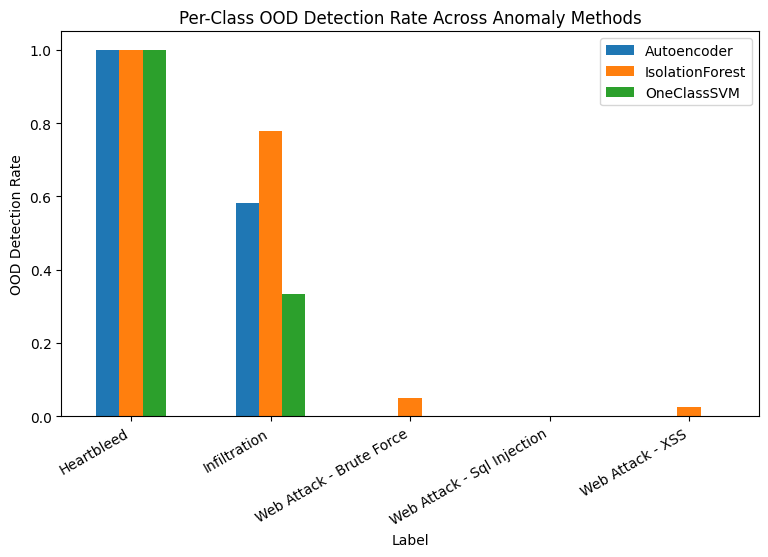

In [40]:
per_class_comparison.plot(kind="bar", figsize=(9,5))
plt.ylabel("OOD Detection Rate")
plt.title("Per-Class OOD Detection Rate Across Anomaly Methods")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.show()

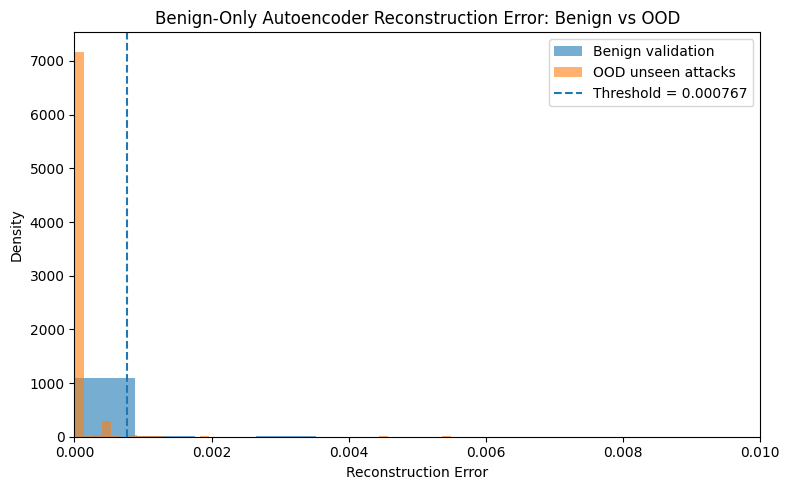

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(val_benign_errors, bins=100, alpha=0.6, label="Benign validation", density=True)
plt.hist(ood_errors_benign, bins=100, alpha=0.6, label="OOD unseen attacks", density=True)
plt.axvline(threshold_benign, linestyle="--", label=f"Threshold = {threshold_benign:.6f}")

plt.xlim(0, 0.01)  # zoom into the useful region
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Benign-Only Autoencoder Reconstruction Error: Benign vs OOD")
plt.legend()
plt.tight_layout()

plt.savefig("reconstruction_error_benign_vs_ood.png", dpi=300, bbox_inches="tight")
plt.show()

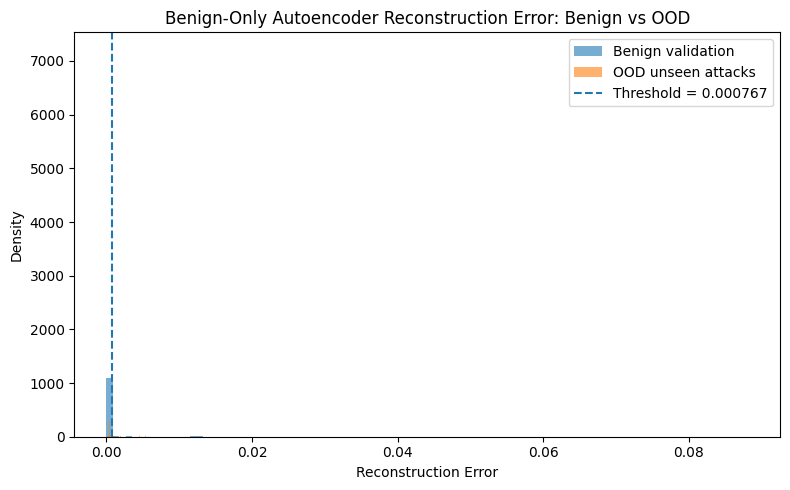

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(val_benign_errors, bins=100, alpha=0.6, label="Benign validation", density=True)
plt.hist(ood_errors_benign, bins=100, alpha=0.6, label="OOD unseen attacks", density=True)
plt.axvline(threshold_benign, linestyle="--", label=f"Threshold = {threshold_benign:.6f}")

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Benign-Only Autoencoder Reconstruction Error: Benign vs OOD")
plt.legend()
plt.tight_layout()

plt.savefig("reconstruction_error_benign_vs_ood_full.png", dpi=300, bbox_inches="tight")
plt.show()

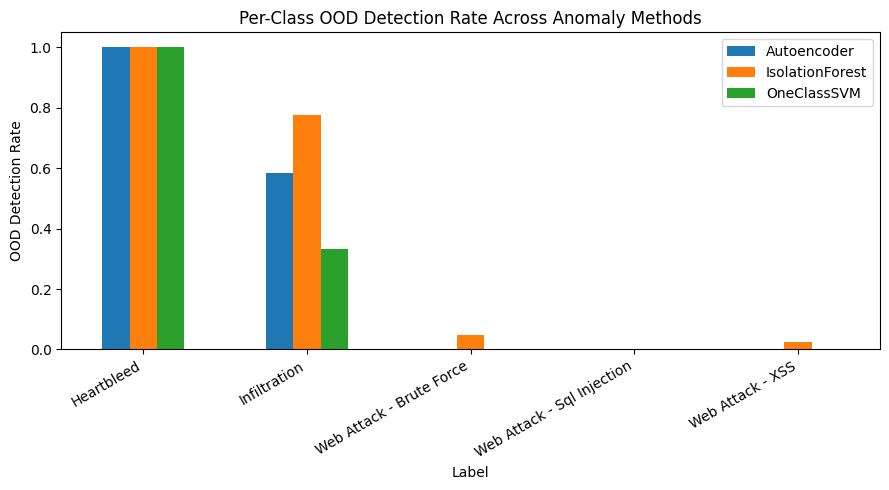

In [43]:
per_class_comparison.plot(kind="bar", figsize=(9,5))
plt.ylabel("OOD Detection Rate")
plt.title("Per-Class OOD Detection Rate Across Anomaly Methods")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig("per_class_ood_detection.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
from google.colab import files
files.download("reconstruction_error_benign_vs_ood.png")
files.download("per_class_ood_detection.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>